In [2]:
import numpy as np
from galpy.orbit import Orbit
from galpy.potential import KeplerPotential
import astropy.constants as acon
import astropy.units as u
import matplotlib.pyplot as plt

In [3]:
from scipy.spatial.transform import Rotation
from numpy.linalg import norm
from scipy.integrate import quad

In [4]:
num = 10000
t = 0
rs = 149600000

v_sun = np.array([12.9, 245.6, 7.78])
v_earth = np.array([0, 0, 0])
v_str = np.array([10, 0, 0])
v_c = v_str #- v_sun

normal = np.array([-v_c[1], v_c[0], 0])
rot = Rotation.from_rotvec(t * normal / norm(normal))
r = rot.apply(v_c)
r = r / norm(r) * rs



In [5]:
num = 301
points = []
z = np.linspace(-4, 4, num)

esc = np.sqrt(acon.GM_sun / (rs * u.km)) / 2

for i in range(num):
    points.append([10 * rs * u.km, -esc.to(u.km / u.s), 0 * u.km / u.s, z[i] * rs * u.km, 0 * u.km / u.s, 0 * u.radian])



In [14]:
# 1. Initialize the orbit [R, vR, vT, z, vz, phi]
o = Orbit(points)

# 2. Define a time array for integration



tf = np.sqrt(2 * (rs * u.km) ** 3 / 3 / acon.GM_sun).to(u.s).value
ts = np.linspace(0*tf, 25 * tf, 1000000) * u.s


pot = KeplerPotential(acon.GM_sun)

# 3. Solve the equations of motion
o.integrate(ts, pot)

rs_kpc = (rs * u.km).to(u.kpc).value
# 4. Plot the resulting trajectory
#plt.xlim(-1 * rs_kpc, 5 * rs_kpc)
#plt.ylim(-2, 2)

(-9.69641163401754e-09, 9.69641163401754e-09)

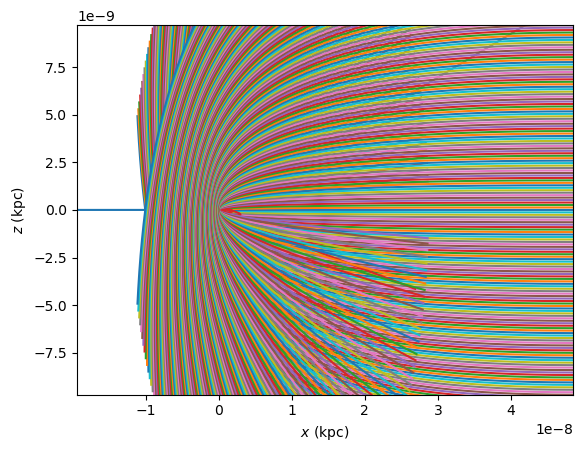

In [15]:
o.plot(d1 = 'x', d2='z')
plt.xlim(-4 * rs_kpc, 10 * rs_kpc)
plt.ylim(-2 * rs_kpc, 2 * rs_kpc)

In [16]:
orbit = o.getOrbit()


In [47]:
z = orbit[:, :, 3]
x = orbit[:, :, 0] * np.cos(orbit[:, :, -1])
mask_ri = x**2 + z**2
mask_ri = np.sqrt(mask_ri)

mask1 = np.arctan(z / x)
mask1[(x < 0) * (z > 0)] = np.pi - np.abs(mask1[(x < 0) * (z > 0)])
mask1[(x < 0) * (z < 0)] = -np.pi + np.abs(mask1[(x < 0) * (z < 0)])

def denPoints(ri, ro, t1, t2):
        
    if t2 > t1:
        dummy = t1
        t1 = t2
        t2 = dummy
        
    
    if t2 < t1 - np.pi:
        theta = t1 - t2
        theta = 2*np.pi - theta
    else:
        theta = t1 - t2
    
    ro = ((ro*rs * u.km).to(u.kpc) / 8).value
    ri = ((ri*rs * u.km).to(u.kpc) / 8).value
    
    area = theta / 2 * (ro ** 2 - ri ** 2)
    
    mask_r = (mask_ri < ro) * (mask_ri > ri)
    
    #assuming t1 > t2
    if t2 < t1 - np.pi:
        if t2 < 0 and t1 > 0:
            print('o', t2, t1)
            return (((mask1 <= t2) + (mask1 >= t1)) * mask_r).sum() / area
        else: 
            print('oj')
            return ((mask1 <= t2) * (mask1 >= t1) * mask_r).sum() / area
    else:
        return ((mask1 <= t1) * (mask1 >= t2) * mask_r).sum() / area

In [54]:
first = denPoints(9.8, 10, np.pi/20, -np.pi/20)
second = denPoints(0.9, 1.1, np.pi - np.pi/40, -np.pi + np.pi/40)
first/second

o -3.0630528372500483 3.0630528372500483


np.float64(1.0189278928958303)

o -3.1258846903218442 3.1258846903218442


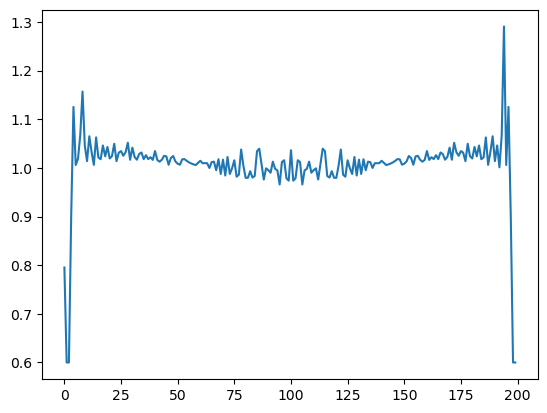

In [55]:
num = 100

def norm(t):
    if t > np.pi:
        return t - 2 * np.pi
    if t <= -np.pi:
        return t + 2 * np.pi
    
    return t

first = denPoints(9.8, 10, np.pi/8, -np.pi/8)

sec = []
for i in range(0, num * 2):
    second = denPoints(0.9, 1.1, 
                       norm(np.pi/num / 2 + i * np.pi/num), 
                       norm(-np.pi/num / 2 + i * np.pi/num))
    sec.append(second/first)
    
plt.clf()
plt.plot(sec)



In [40]:
denPoints(0.9, 1.1, np.pi/2 - np.pi/20, np.pi/2 + np.pi/20) / first

np.float64(1.0154133412118613)

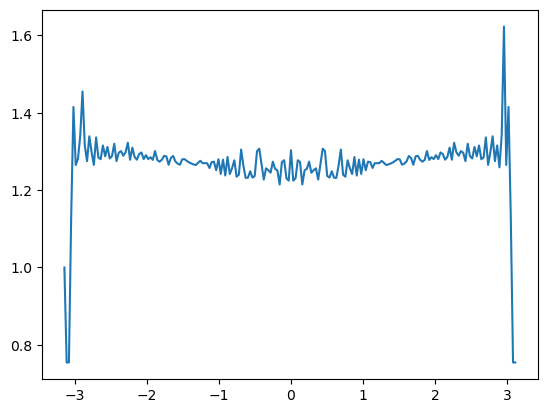

In [42]:
plt.clf()
t = np.arange(0, 2 * np.pi, np.pi/num)
plt.plot(t - np.pi, np.array(sec)/sec[0])

In [ ]:
np.min(sec)

np.float64(0.6163311899686934)